In [1]:
import pandas as pd

In [2]:
GMR = pd.read_csv("Mobile Reviews Sentiment null.csv")

In [ ]:
GMR.info()

In [ ]:
GMR

In [ ]:
GMR.isna().sum()

In [ ]:
GMR['sentiment']

In [3]:
GMR.groupby('brand')['price_usd'].mean()

brand
Apple       1103.150627
Google       805.125586
Motorola     506.540921
OnePlus      672.158404
Realme       393.228317
Samsung      900.504534
Xiaomi       449.753290
Name: price_usd, dtype: float64

In [4]:
GMR['price_local'] = (
    GMR['price_local'].astype(str).str.strip()
    .str.extract(r'([\d,]+\.?\d*)$')[0]
    .str.replace(',', '', regex=False)
)
GMR['price_local'] = pd.to_numeric(GMR['price_local'], errors='coerce')

In [5]:
GMR['rating'] = GMR['rating'].fillna(round(GMR['rating'].mean(),1))

In [ ]:
GMR.isna().sum()

In [6]:
GMR['sentiment'] = GMR['sentiment'].fillna(GMR['sentiment'].mode()[0])

In [7]:
GMR['source'] = GMR['source'].fillna('Unlisted')

In [9]:
GMR[GMR['source'] == 'Unlisted']

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
13,14,Mark Diaz,32,Realme,Realme Narzo 70,247.88,342.07,CAD,1.38,2.0,...,English,5/19/2024,False,1,3,2,1,2,2,Unlisted
53,54,Ashley Lee,48,Google,Pixel 8,1048.91,1604.83,AUD,1.53,3.0,...,English,2/1/2025,True,4,2,1,5,3,4,Unlisted
54,55,Logan Sami,18,OnePlus,OnePlus Nord 3,473.95,39337.85,INR,83.00,5.0,...,Hindi,8/3/2023,True,5,2,2,3,3,6,Unlisted
71,72,Paul Jones,40,Apple,iPhone 14,1266.69,NaN,CAD,1.38,1.0,...,English,10/2/2024,True,2,2,1,1,1,2,Unlisted
106,107,Hans-Christian Losekann B.Sc.,44,OnePlus,OnePlus Nord 3,752.73,700.04,EUR,0.93,2.0,...,German,8/18/2025,True,2,1,1,1,1,4,Unlisted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49931,49932,Randy Fisher,24,Realme,Realme Narzo 70,451.36,1656.49,AED,3.67,4.0,...,English,9/4/2023,True,4,3,3,3,4,6,Unlisted
49956,49957,Julia Curtis,40,Samsung,Galaxy S24,776.07,605.33,GBP,0.78,4.0,...,English,1/15/2024,True,4,2,3,4,3,3,Unlisted
49969,49970,Cheryl Campos,41,Xiaomi,Mi 13 Pro,NaN,488.71,AUD,1.53,3.0,...,English,9/17/2025,True,2,1,3,2,2,0,Unlisted
49993,49994,Shawn Mueller,47,Google,Pixel 7a,949.60,1310.45,CAD,1.38,5.0,...,English,8/26/2023,True,5,5,5,5,4,2,Unlisted


In [8]:
GMR.dropna(inplace=True)

In [9]:
GMR.duplicated().sum()

np.int64(0)

In [ ]:
GMR.isna().sum()

In [10]:
GMR

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,49995,Netra Srinivas,26,Xiaomi,Poco X6,300.72,24959.76,INR,83.00,5.0,...,Hindi,6/5/2025,True,5,5,4,5,5,3,eBay
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,804.93,AUD,1.53,4.0,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,1395.13,AUD,1.53,3.0,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,4240.02,AED,3.67,3.1,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon


In [11]:
GMR.to_csv('GMR.csv',index=False)

## Data Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

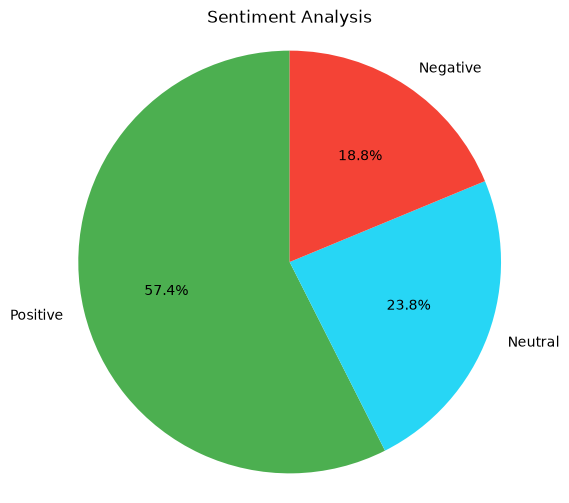

In [12]:
counts = GMR['sentiment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts,labels=counts.index,autopct='%1.1f%%',colors=['#4CAF50', '#27D6F5', '#F44336',],startangle=90,)
plt.title('Sentiment Analysis')
plt.axis('equal')
plt.show()

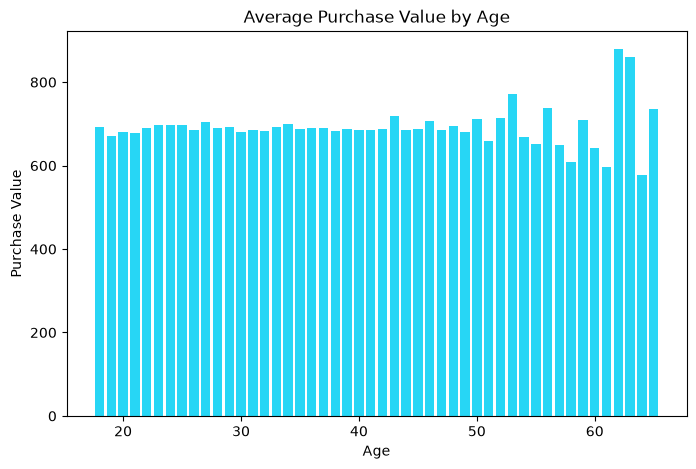

In [13]:
age_price =  GMR.groupby('age')['price_usd'].mean().sort_index()

plt.figure(figsize=(8,5))
plt.bar(age_price.index,age_price.values, color='#27D6F5')
plt.title('Average Purchase Value by Age')
plt.xlabel('Age')
plt.ylabel('Purchase Value')
plt.show()

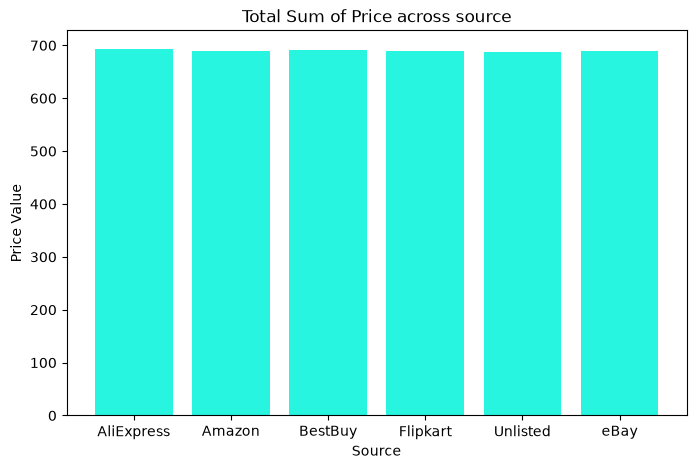

In [14]:
source_value = GMR.groupby('source')['price_usd'].mean()

plt.figure(figsize=(8,5))
plt.bar(source_value.index,source_value.values, color='#27F5E0')
plt.title('Total Sum of Price across source')
plt.xlabel('Source')
plt.ylabel('Price Value')
plt.show()

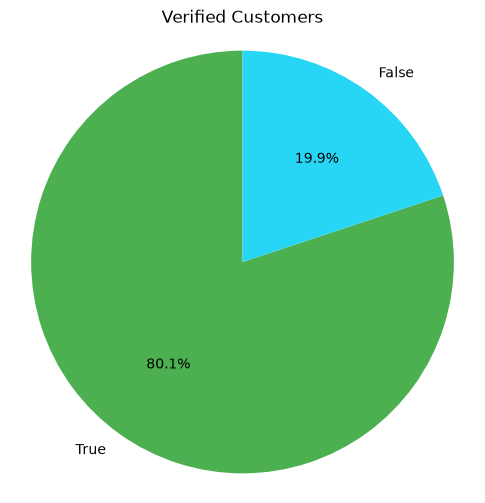

In [15]:
verified = GMR['verified_purchase'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(verified,labels=verified.index,autopct='%1.1f%%',colors=['#4CAF50', '#27D6F5',],startangle=90,)
plt.title('Verified Customers')
plt.axis('equal')
plt.show()

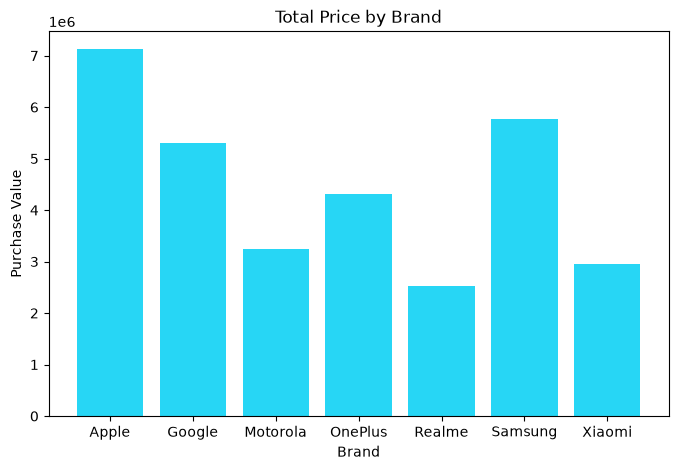

In [16]:
age_price =  GMR.groupby('brand')['price_usd'].sum().sort_index()

plt.figure(figsize=(8,5))
plt.bar(age_price.index,age_price.values, color='#27D6F5')
plt.title('Total Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Purchase Value')
plt.show()

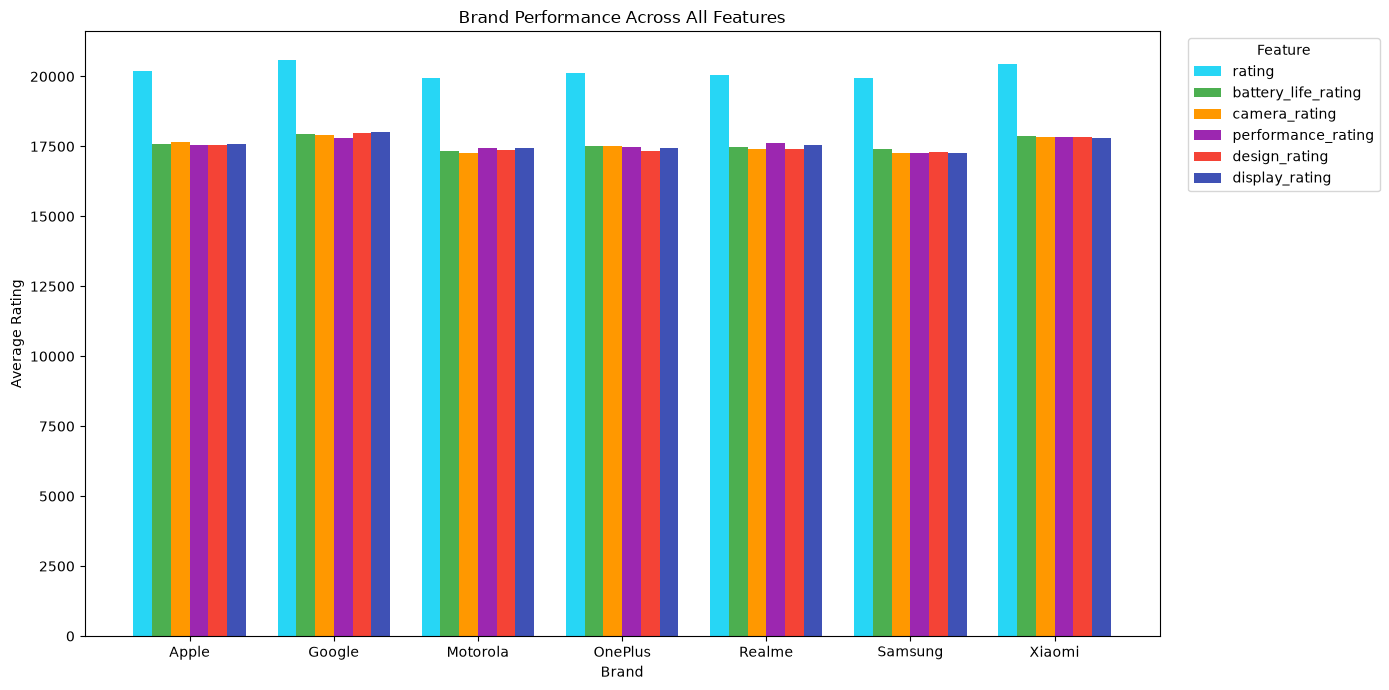

In [49]:
rating_cols = ['rating','battery_life_rating','camera_rating','performance_rating','design_rating','display_rating']
brand_perf  = GMR.groupby('brand')[rating_cols].sum()
#Group
x = np.arange(len(brand_perf.index))
width= 0.13
n_features = len(rating_cols)
#Visualize
plt.figure(figsize=(14,7))
colors = ['#27D6F5', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#3F51B5']
for i,col in enumerate(rating_cols):
    offset = (i-n_features/2)*width+width/2
    plt.bar(x+offset,brand_perf[col],width,label=col,color=colors[i])
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.title('Brand Performance Across All Features')
plt.xticks(x, brand_perf.index, rotation=0)
plt.legend(title='Feature', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

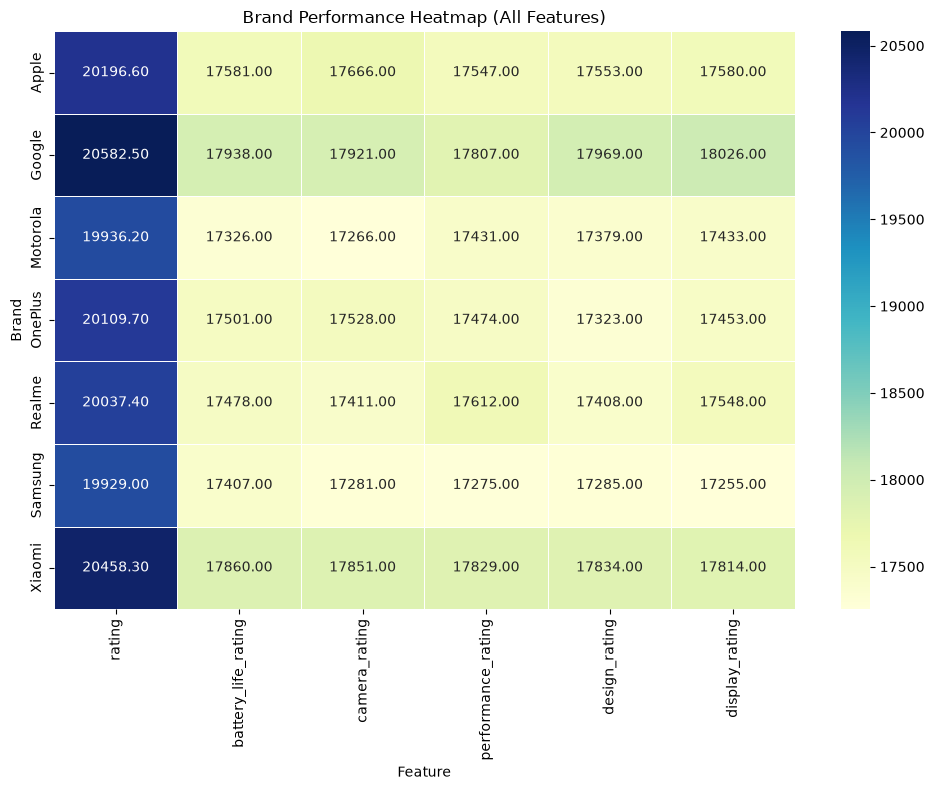

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(brand_perf, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Brand Performance Heatmap (All Features)')
plt.xlabel('Feature')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

## K Means Clustering

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

product_df = GMR.groupby(['brand','model']).agg(avg_price=('price_usd', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_battery=('battery_life_rating', 'mean'),
    avg_camera=('camera_rating', 'mean'),
    avg_performance=('performance_rating', 'mean')
).reset_index()

In [18]:
features = ['avg_price', 'avg_rating', 'avg_battery', 'avg_camera', 'avg_performance']
X_scaled = StandardScaler().fit_transform(product_df[features])

In [19]:
K_means = KMeans(n_clusters=4,max_iter=300,random_state=42,n_init=10)
product_df['cluster'] = K_means.fit_predict(X_scaled)

In [20]:
cluster_summary = product_df.groupby('cluster')['avg_price'].mean().sort_values()
print(cluster_summary)

cluster
0     517.004716
1     737.096065
3     968.319899
2    1104.717614
Name: avg_price, dtype: float64


In [21]:
tier_labels = {cluster_summary.index[0]: 'Budget',
               cluster_summary.index[1]: 'Mid-range',
               cluster_summary.index[2]: 'Premium',
               cluster_summary.index[3]: 'Luxury'}
product_df['segment'] = product_df['cluster'].map(tier_labels)
product_df

,brand,model,avg_price,avg_rating,avg_battery,avg_camera,avg_performance,cluster,segment
0,Apple,iPhone 13,1107.698984,3.162219,2.759352,2.772444,2.777431,2,Luxury
1,Apple,iPhone 14,1101.736244,3.168284,2.728234,2.763682,2.718905,2,Luxury
2,Apple,iPhone 15 Pro,1102.141695,3.085040,2.676598,2.700807,2.646803,3,Premium
3,Apple,iPhone SE,1102.606552,3.104172,2.733742,2.714110,2.733742,1,Mid-range
4,Google,Pixel 6,807.950788,3.119842,2.716273,2.710246,2.692165,0,Budget
5,Google,Pixel 7a,807.898521,3.134785,2.733896,2.741448,2.739227,1,Mid-range
6,Google,Pixel 8,799.465547,3.136410,2.734195,2.724504,2.692201,1,Mid-range
7,Motorola,Edge 50,509.434786,3.092823,2.673479,2.704373,2.709125,0,Budget
8,Motorola,Moto G Power,504.472884,3.120432,2.707844,2.683889,2.708314,0,Budget
9,Motorola,Razr 40,506.296059,3.116904,2.726688,2.692696,2.740009,0,Budget


## Recommendation System

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [23]:
similarity_matrix = cosine_similarity(X_scaled)

In [24]:
product_df['product_label'] = product_df['brand'] +' '+ product_df['model']
sim_df =  pd.DataFrame(similarity_matrix,index=product_df['product_label'],columns=product_df['product_label'])

In [25]:
sim_df

product_label,Apple iPhone 13,Apple iPhone 14,Apple iPhone 15 Pro,Apple iPhone SE,Google Pixel 6,Google Pixel 7a,Google Pixel 8,Motorola Edge 50,Motorola Moto G Power,Motorola Razr 40,...,OnePlus OnePlus Nord 3,Realme Realme 12 Pro,Realme Realme Narzo 70,Samsung Galaxy A55,Samsung Galaxy Note 20,Samsung Galaxy S24,Samsung Galaxy Z Flip,Xiaomi Mi 13 Pro,Xiaomi Poco X6,Xiaomi Redmi Note 13
product_label,,,,,,,,,,,,,,,,,,,,,
Apple iPhone 13,1.000000,0.830397,-0.614831,0.379893,-0.534975,0.978073,0.489026,-0.819314,-0.840220,-0.338912,...,0.814777,0.438218,-0.475415,-0.708277,0.900463,-0.818286,0.973392,-0.961523,0.318792,-0.531653
Apple iPhone 14,0.830397,1.000000,-0.258301,0.154043,-0.127142,0.785089,0.637153,-0.634168,-0.768371,-0.709621,...,0.586371,0.163892,-0.782671,-0.555436,0.652774,-0.572016,0.842573,-0.823792,0.058958,-0.626667
Apple iPhone 15 Pro,-0.614831,-0.258301,1.000000,0.165962,0.834530,-0.682633,-0.241230,0.614038,0.207757,-0.425971,...,-0.919944,-0.934616,-0.289637,0.744129,-0.660319,0.893497,-0.493559,0.574558,-0.725246,-0.115592
Apple iPhone SE,0.379893,0.154043,0.165962,1.000000,0.077016,0.256432,0.036061,-0.383495,-0.536542,-0.211920,...,-0.115231,-0.417962,-0.425157,0.229734,0.468371,0.102611,0.415842,-0.372085,-0.397318,-0.570452
Google Pixel 6,-0.534975,-0.127142,0.834530,0.077016,1.000000,-0.645320,0.235477,0.255417,0.241925,-0.412553,...,-0.805932,-0.860680,-0.438707,0.848669,-0.481138,0.844645,-0.524943,0.524717,-0.923929,-0.057654
Google Pixel 7a,0.978073,0.785089,-0.682633,0.256432,-0.645320,1.000000,0.432166,-0.753334,-0.831074,-0.298737,...,0.865900,0.533582,-0.332588,-0.812087,0.821799,-0.898673,0.949647,-0.911752,0.452556,-0.382100
Google Pixel 8,0.489026,0.637153,-0.241230,0.036061,0.235477,0.432166,1.000000,-0.778014,-0.466720,-0.465205,...,0.325101,0.019592,-0.574954,-0.057861,0.448030,-0.287196,0.340184,-0.369104,-0.360322,-0.100163
Motorola Edge 50,-0.819314,-0.634168,0.614038,-0.383495,0.255417,-0.753334,-0.778014,1.000000,0.629441,0.158363,...,-0.658395,-0.334466,0.434705,0.334142,-0.876586,0.611634,-0.680933,0.738193,0.016755,0.313558
Motorola Moto G Power,-0.840220,-0.768371,0.207757,-0.536542,0.241925,-0.831074,-0.466720,0.629441,1.000000,0.666073,...,-0.444941,0.009921,0.569766,0.461768,-0.596578,0.532804,-0.852866,0.720397,0.000995,0.441827


In [27]:
def recommend_similar(product_name,top_n=5):
    if product_name not in sim_df.index:
        return f" '{product_name}' not found. Try one of: {list(sim_df.index[:5])}..."
    scores = sim_df[product_name].drop(product_name)
    top_matches = scores.sort_values(ascending=False).head(top_n)

    result = product_df.set_index('product_label').loc[top_matches.index,features].copy()
    result['similarity_score'] = top_matches.values.round(3)
    return result
recommend_similar(input(),top_n=5)

 Xiaomi Redmi Note 13


,avg_price,avg_rating,avg_battery,avg_camera,avg_performance,similarity_score
product_label,,,,,,
Realme Realme Narzo 70,392.229280,3.105717,2.721570,2.709209,2.731768,0.786
Xiaomi Mi 13 Pro,448.208675,3.089145,2.703302,2.691995,2.664858,0.692
Motorola Moto G Power,504.472884,3.120432,2.707844,2.683889,2.708314,0.442
Motorola Razr 40,506.296059,3.116904,2.726688,2.692696,2.740009,0.440
Motorola Edge 50,509.434786,3.092823,2.673479,2.704373,2.709125,0.314


## Importing Model

In [28]:
import joblib
joblib.dump(K_means,'K_means_model.pkl')
joblib.dump(similarity_matrix,'Model_recommendation.pkl')

['Model_recommendation.pkl']